# CDM (Code Division Multiplexing) / CDMA の原理

このノートブックでは、符号分割多重 (CDM) や符号分割多元接続 (CDMA) の基本原理を、簡単なPythonコードでシミュレーションして理解します。

**ポイント:**
1. **直交符号 (Orthogonal Codes):** 互いに干渉しない特殊な符号（例：ウォルシュ符号）を使用します。
2. **拡散 (Spreading):** 元のデータを符号と掛け合わせて、帯域を広げます。
3. **多重化 (Multiplexing):** 複数のユーザーの拡散信号を足し合わせます。
4. **逆拡散 (Despreading):** 受信側で自分の符号と同じ符号を掛けることで、目的のデータだけを取り出します。

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline
# グラフのラベルは英語表記にします

## 1. 直交符号の準備

ここでは簡単な例として、長さ4のウォルシュ符号を使います。
直交性とは、「異なる符号同士の積の和（内積）がゼロになる」性質のことです。

In [2]:
# 長さ4のコードの定義
code_A = np.array([1, 1, 1, 1])   # User A のコード
code_B = np.array([1, -1, 1, -1]) # User B のコード

print(f"Code A: {code_A}")
print(f"Code B: {code_B}")

# 直交性の確認 (内積が0になるか)
dot_product = np.dot(code_A, code_B)
print(f"Dot Product (A . B): {dot_product}")

if dot_product == 0:
    print("-> Orthogonal (直交しています)")
else:
    print("-> Not Orthogonal")

Code A: [1 1 1 1]
Code B: [ 1 -1  1 -1]
Dot Product (A . B): 0
-> Orthogonal (直交しています)


## 2. データの拡散 (Spreading)

ユーザーAとユーザーBがそれぞれデータを送信します。
データビットが `1` のときはコードをそのまま送信し、`-1` のときはコードを反転して送信します。

In [3]:
# 送信データ (1 bitずつとします)
data_A = 1
data_B = -1

print(f"Data A: {data_A}")
print(f"Data B: {data_B}")

# 拡散処理: データ × コード
spread_signal_A = data_A * code_A
spread_signal_B = data_B * code_B

print(f"Spread Signal A: {spread_signal_A}")
print(f"Spread Signal B: {spread_signal_B}")

Data A: 1
Data B: -1
Spread Signal A: [1 1 1 1]
Spread Signal B: [-1  1 -1  1]


## 3. 多重化 (Multiplexing)

空間（またはケーブル）上では、両方の信号が混ざり合います（足し算されます）。

Multiplexed Signal: [0 2 0 2]


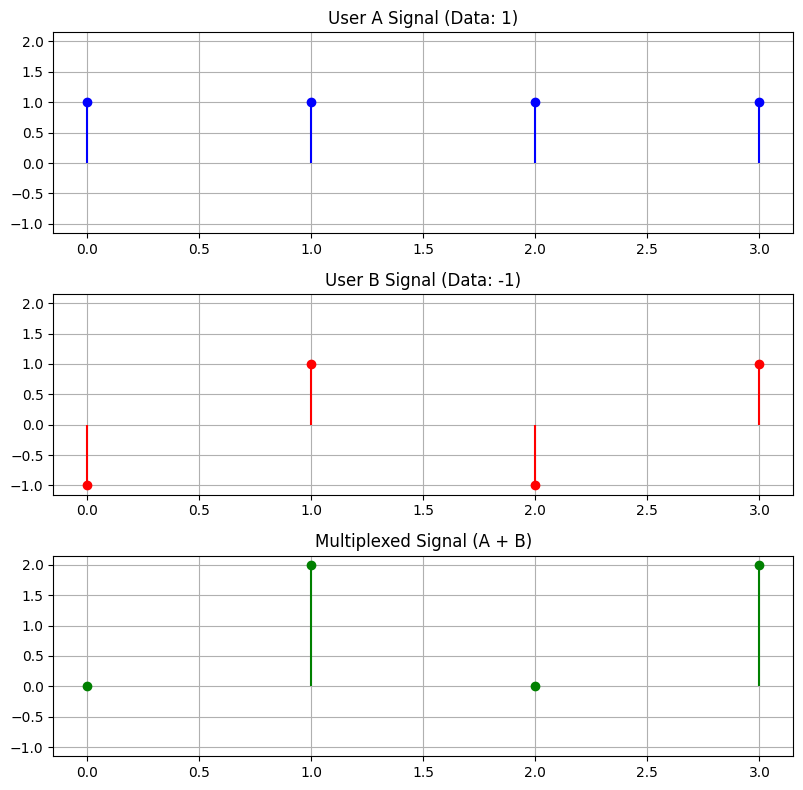

In [4]:
# 信号の合成
mux_signal = spread_signal_A + spread_signal_B

print(f"Multiplexed Signal: {mux_signal}")

# グラフで可視化
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(8, 8), sharey=True)

x = np.arange(4)

ax1.stem(x, spread_signal_A, linefmt='b-', markerfmt='bo', basefmt=' ')
ax1.set_title(f'User A Signal (Data: {data_A})')
ax1.grid(True)

ax2.stem(x, spread_signal_B, linefmt='r-', markerfmt='ro', basefmt=' ')
ax2.set_title(f'User B Signal (Data: {data_B})')
ax2.grid(True)

ax3.stem(x, mux_signal, linefmt='g-', markerfmt='go', basefmt=' ')
ax3.set_title('Multiplexed Signal (A + B)')
ax3.grid(True)

plt.tight_layout()
plt.show()

## 4. 逆拡散 (Despreading) と復調

受信側では、混ざった信号 `mux_signal` を受け取ります。
ここからユーザーAのデータを取り出すには、**ユーザーAのコード** との内積をとります。

数式的なイメージ:
$$(A+B) \cdot CodeA = A \cdot CodeA + B \cdot CodeA$$
ここで、$A \cdot CodeA$ は相関が高くなり、$B \cdot CodeA$ は直交性により 0 になります。

In [5]:
# 受信信号を User A のコードで逆拡散
correlation_A = np.dot(mux_signal, code_A)

# コード長で割って正規化
decoded_data_A = correlation_A / len(code_A)

print(f"Correlation Result (A): {correlation_A}")
print(f"Decoded Data A: {decoded_data_A}")

if decoded_data_A == data_A:
    print("-> Correctly decoded User A!")
else:
    print("-> Decoding failed.")


# 念のため User B も復調してみる
correlation_B = np.dot(mux_signal, code_B)
decoded_data_B = correlation_B / len(code_B)

print(f"\nCorrelation Result (B): {correlation_B}")
print(f"Decoded Data B: {decoded_data_B}")

if decoded_data_B == data_B:
    print("-> Correctly decoded User B!")
else:
    print("-> Decoding failed.")

Correlation Result (A): 4
Decoded Data A: 1.0
-> Correctly decoded User A!

Correlation Result (B): -4
Decoded Data B: -1.0
-> Correctly decoded User B!


## まとめ

このように、それぞれのユーザーに「直交する符号」を割り当てることで、同じ周波数帯・同じ時間に信号を重ね合わせても、お互いに干渉することなくデータを取り出すことができます。

実際のCDMA（携帯電話の3Gなど）では、もっと長い符号や、擬似乱数系列（PN系列）などが使われますが、基本的な原理はこれと同じです。